# Transferencia de Aprendizaje (Transfer Learning) con MobileNetV2

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Asignatura Ministerial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de esta sesión es comprender e implementar la técnica de **Transferencia de Aprendizaje (Transfer Learning)**. Reutilizaremos los filtros y características espaciales previamente aprendidos por la red eficiente **MobileNetV2** (entrenada en ImageNet), congelando su base convolucional y entrenando únicamente una nueva capa de salida personalizada para clasificar un dataset local de perros y gatos.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Explicar los fundamentos, ventajas y casos de uso prácticos de la Transferencia de Aprendizaje frente al entrenamiento desde cero.
2. Cargar un modelo convolucional preentrenado de Keras (`MobileNetV2`) excluyendo sus capas superiores de clasificación final.
3. Congelar los pesos de las capas convolucionales base para evitar que se actualicen durante el entrenamiento.
4. Aplicar técnicas de **Aumento de Datos (Data Augmentation)** mediante Keras para expandir artificialmente el dataset de entrenamiento y mitigar el sobreajuste.
5. Entrenar y evaluar el modelo híbrido resultante, analizando el comportamiento de las curvas de precisión y error.

## Terminología clave (Microglosario)

*   **Transferencia de Aprendizaje (Transfer Learning):** Metodología en aprendizaje profundo que consiste en tomar un modelo que ya ha sido entrenado en un gran dominio general y adaptarlo a un nuevo problema específico con menos datos y recursos computacionales.
*   **MobileNetV2:** Red neuronal convolucional profunda ligera y altamente optimizada para dispositivos embebidos y móviles, caracterizada por convoluciones separables en profundidad y bloques residuales invertidos.
*   **Congelamiento de Capas (Freezing):** Técnica para bloquear los pesos de ciertas capas de un modelo preentrenado, haciendo que sus parámetros permanezcan constantes e inalterables durante la fase de retropropagación del entrenamiento.
*   **Aumento de Datos (Data Augmentation):** Estrategia para generar variaciones aleatorias pero lógicas en las imágenes de entrada (como rotaciones, zooms, recortes) con el fin de robustecer la generalización de la red.

## 1. Configuración de Librerías y Dependencias

Importemos las librerías necesarias de TensorFlow/Keras para cargar el modelo preentrenado, preparar los generadores de imágenes y configurar las transformaciones del dataset.

In [ ]:
# Este bloque instala las dependencias necesarias para el notebook.
# numpy se fija en <2 porque TensorFlow y algunas versiones de Pillow
# tienen incompatibilidades con la API de numpy 2.x.
print('✦ Instalando dependencias necesarias en el sistema...')
!pip install -q matplotlib pillow "numpy<2"
print('✓ Librerías instaladas con éxito.')


✦ Instalando dependencias necesarias en el sistema...
✓ Librerías instaladas con éxito.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [ ]:
# Este bloque importa las herramientas necesarias para el flujo de Transfer Learning:
# el modelo preentrenado, las capas para construir la nueva cabeza clasificadora,
# y los utilitarios para manejo de datos e imágenes.
print('✦ Cargando librerías y configurando TensorFlow...')
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2  # El modelo preentrenado en ImageNet que usaremos como extractor de características.
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout  # Capas que forman la nueva cabeza clasificadora adaptada a nuestro problema.
from tensorflow.keras.models import Sequential  # Permite apilar la base preentrenada con las nuevas capas de forma lineal.
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Genera lotes de imágenes desde disco con aumentación de datos en tiempo real.
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import shutil
import os
print('✓ Entorno listo para Transfer Learning.')


✦ Cargando librerías y configurando TensorFlow...
✓ Entorno listo para Transfer Learning.


## 2. Preparación y Extracción del Dataset Local

Para realizar este laboratorio de forma local o en la nube, descomprimiremos los archivos zip `perros.zip` y `gatos.zip` colocados en la carpeta `datos/` (o en la raíz del entorno), unificándolos bajo un directorio estructurado llamado `dataset/`.

In [ ]:
# Comentario general: este bloque carga y organiza el conjunto de datos; un modelo aprende a partir de ejemplos; 
# por eso primero se define de donde vienen las imagenes o mediciones y como se separan sus etiquetas.
print('✦ Configurando carpetas para el dataset local...')  
os.makedirs('dataset', exist_ok=True)  #

# Descomprimimos los zips locales si existen en la raíz o en datos/
for zip_name, class_name in [('perros.zip', 'perro'), ('gatos.zip', 'gato')]:  
    zip_path = zip_name  
    if not os.path.exists(zip_path):  
        zip_path = os.path.join('datos', zip_name)  
        
    if os.path.exists(zip_path):  
        print(f'  ✦ Descomprimiendo {zip_path}...')  
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:  # Abre un contexto controlado para manejar recursos de forma segura.
            zip_ref.extractall('dataset')  
        
        # Si el zip crea una carpeta anidada de nombre original, la renombramos a class_name
        orig_dir = zip_name.replace('.zip', '') # 'perros' o 'gatos'
        orig_path = os.path.join('dataset', orig_dir)  
        dest_path = os.path.join('dataset', class_name)  
        
        if os.path.exists(orig_path):  
            if os.path.exists(dest_path):  
                shutil.rmtree(dest_path)  
            os.rename(orig_path, dest_path)  
            print(f'  ✓ Clase "{class_name}" lista en {dest_path}.')  
        else:  # Ejecuta esta rama cuando las condiciones anteriores no se cumplen.
            print(f'  ✓ Clase "{class_name}" extraída correctamente.')  
    else:  # Ejecuta esta rama cuando las condiciones anteriores no se cumplen.
        print(f'  ⚠ Archivo {zip_name} no encontrado en la raíz ni en datos/.')  

print('\n✓ Dataset estructurado con éxito.')  

✦ Configurando carpetas para el dataset local...
  ✦ Descomprimiendo datos\perros.zip...
  ✓ Clase "perro" lista en dataset\perro.
  ✦ Descomprimiendo datos\gatos.zip...
  ✓ Clase "gato" lista en dataset\gato.

✓ Dataset estructurado con éxito.


## 3. Configuración de Aumento de Datos y Generadores

Para ampliar la robustez del modelo, utilizaremos `ImageDataGenerator` para aplicar transformaciones de aumento de datos aleatorias al conjunto de entrenamiento y normalizar los valores al rango $[0, 1]$.

In [ ]:
# Este bloque configura la aumentación de datos y crea los generadores de lotes para
# entrenamiento y validación. La aumentación expone al modelo a variaciones artificiales
# de las imágenes, reduciendo el sobreajuste sin necesidad de más datos reales.
print('✦ Configurando ImageDataGenerator con Data Augmentation...')

# La aumentación solo se aplica automáticamente al subset 'training', no al de validación,
# lo que garantiza que evaluamos el modelo con imágenes sin distorsionar.
datagen = ImageDataGenerator(
    rescale=1. / 255.0,            # MobileNetV2 espera entradas en [0.0, 1.0], no en [0, 255].
    rotation_range=10,             # Rotaciones aleatorias de ±10 grados
    width_shift_range=0.15,        # Desplazamientos horizontales de ±15%
    height_shift_range=0.15,       # Desplazamientos verticales de ±15%
    shear_range=5,                 # Distorsiones de corte (shear)
    zoom_range=[0.7, 1.3],         # Zooms variables entre 70% y 130%
    validation_split=0.2           # El 20% de las imágenes se reserva para validación, el 80% restante para entrenamiento.
)

print('✦ Cargando lotes de entrenamiento...')
data_gen_entrenamiento = datagen.flow_from_directory(
    'dataset',
    target_size=(224, 224),  # MobileNetV2 fue entrenado con imágenes de 224×224 píxeles.
    batch_size=32,           # Tamaño de lote estándar: equilibrio entre uso de memoria y estabilidad del gradiente.
    shuffle=True,            # Mezclar evita que el modelo aprenda el orden de las clases en vez de sus características.
    subset='training'
)

print('✦ Cargando lotes de validación...')
data_gen_pruebas = datagen.flow_from_directory(
    'dataset',
    target_size=(224, 224),
    batch_size=32,
    shuffle=True,
    subset='validation'     # Mismo directorio que entrenamiento; el split lo maneja el datagen según validation_split.
)

print('\n✓ Generadores y lotes listos.')


✦ Configurando ImageDataGenerator con Data Augmentation...
✦ Cargando lotes de entrenamiento...
Found 625 images belonging to 2 classes.
✦ Cargando lotes de validación...
Found 155 images belonging to 2 classes.

✓ Generadores y lotes listos.


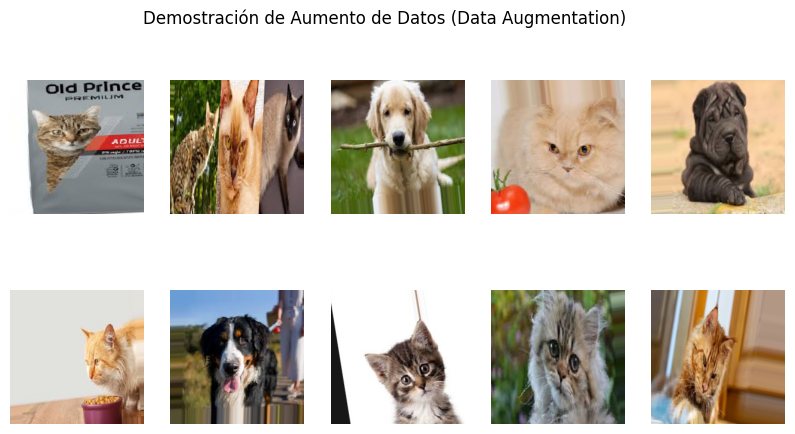

In [ ]:
# Comentario general: este bloque visualiza datos, resultados o curvas de aprendizaje; las imagenes y graficos 
# facilitan detectar patrones, errores, sesgos y cambios en el entrenamiento.
# Tomamos un lote del generador para visualizar los aumentos aplicados
for imagenes, etiquetas in data_gen_entrenamiento:  # Inicia un bucle para recorrer elementos de una coleccion.
    plt.figure(figsize=(10, 5))  # Crea una figura para graficar resultados o imagenes.
    for i in range(10):  # Inicia un bucle para recorrer elementos de una coleccion.
        plt.subplot(2, 5, i + 1)  # Selecciona la posicion del grafico dentro de una grilla.
        plt.imshow(imagenes[i])  # Muestra una imagen o mapa de activacion en pantalla.
        plt.axis('off')  # Configura o dibuja una visualizacion para interpretar los datos.
    break  # Interrumpe el bucle cuando ya se obtuvo lo necesario.
plt.suptitle('Demostración de Aumento de Datos (Data Augmentation)')  # Configura o dibuja una visualizacion para interpretar los datos.
plt.show()  # Renderiza y muestra la visualizacion completa.

**Data Augmentation** (aumento de datos) es una técnica que crea variaciones artificiales de las imágenes de entrenamiento mediante transformaciones como:

- Rotaciones y recortes.
- Volteos horizontales.
- Cambios de tamaño, brillo o contraste.
- Desplazamientos y zoom.

Se utiliza para aumentar la diversidad del conjunto de entrenamiento sin recopilar imágenes nuevas. Esto ayuda a reducir el **sobreajuste** (*overfitting*) y permite que el modelo generalice mejor ante imágenes que nunca vio.

Ejemplo: a partir de una foto de una zapatilla se generan versiones rotadas, recortadas o con distinta iluminación, conservando la misma etiqueta.

## 4. Carga de MobileNetV2 y Congelamiento de Capas

Cargaremos la red convolucional **MobileNetV2** preentrenada en ImageNet omitiendo su clasificador superior (`include_top=False`). Luego, congelaremos todas las capas base convolucionales para preservar sus filtros visuales.

In [ ]:
# Este bloque implementa el primer paso del Transfer Learning: cargar la red convolucional
# preentrenada como extractor de características y congelar sus pesos para preservar
# el conocimiento adquirido en ImageNet sin modificarlo durante nuestro entrenamiento.
print('✦ Descargando y cargando MobileNetV2 preentrenado en ImageNet...')

modelo_base = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,   # Descartamos la cabeza clasificadora original de 1000 clases de ImageNet; la reemplazaremos con la nuestra.
    weights='imagenet'   # Cargamos los pesos preentrenados para reutilizar características ya aprendidas (bordes, texturas, formas).
)

# Congelamos la base para que el entrenamiento solo actualice nuestra nueva cabeza clasificadora.
# Sin este paso, el gradiente modificaría los pesos preentrenados y destruiría el conocimiento
# acumulado (fenómeno conocido como "catastrophic forgetting").
modelo_base.trainable = False
print('✓ Capas convolucionales de MobileNetV2 congeladas con éxito.')


✦ Descargando y cargando MobileNetV2 preentrenado en ImageNet...
✓ Capas convolucionales de MobileNetV2 congeladas con éxito.


## 5. Ensamblaje y Compilación del Modelo Híbrido

Construiremos el nuevo modelo conectando las capas convolucionales base congeladas a un promedio espacial bidimensional (`GlobalAveragePooling2D`) y a una capa densa final de salida softmax para las dos clases perro y gato.

In [ ]:
# Este bloque construye la cabeza clasificadora sobre la base convolucional congelada
# y configura el proceso de entrenamiento. Solo los parámetros de la cabeza se actualizarán;
# los de la base permanecen fijos tal como se definió en el bloque anterior.
print('✦ Ensamblando la arquitectura híbrida para Transfer Learning...')

modelo = Sequential([
    modelo_base,                   # Extractor de características preentrenado y congelado; no tiene parámetros entrenables.
    GlobalAveragePooling2D(),      # Colapsa los mapas espaciales a un vector promediando cada canal; reduce parámetros frente a Flatten y generaliza mejor.
    Dropout(0.2),                  # Desactiva aleatoriamente el 20% de las neuronas en cada paso para reducir la dependencia entre ellas.
    Dense(2, activation='softmax') # Una neurona por clase; softmax convierte los logits en probabilidades que suman 1.
])

print('✦ Compilando el modelo con optimizador Adam a baja tasa de aprendizaje...')
modelo.compile(
    optimizer=Adam(learning_rate=0.0001), # Tasa muy baja para no desestabilizar las capas adyacentes a la base congelada.
    loss='categorical_crossentropy',      # Requiere etiquetas en formato one-hot, que es lo que produce flow_from_directory por defecto.
    metrics=['accuracy']
)

print('✓ Modelo compilado con éxito.\n')
modelo.summary()  # Permite verificar cuántos parámetros son entrenables vs. congelados.


✦ Ensamblando la arquitectura híbrida para Transfer Learning...
✦ Compilando el modelo con optimizador Adam a baja tasa de aprendizaje...
✓ Modelo compilado con éxito.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Los resultados indican que el modelo de *transfer learning* se construyó y compiló correctamente para clasificar imágenes en **dos clases**.

- **MobileNetV2:** es la base preentrenada. Sus **2.257.984 parámetros están congelados**, por lo que conserva el conocimiento visual aprendido previamente y no se modifica durante esta etapa.

- **Salida `(None, 7, 7, 1280)`:** cada imagen se convierte en 1280 mapas de características. `None` representa un tamaño de lote variable.

- **GlobalAveragePooling2D:** resume cada mapa y produce un vector de **1280 características**, sin agregar parámetros.

- **Dropout:** desactiva aleatoriamente algunas características durante el entrenamiento para disminuir el sobreajuste.

- **Dense con salida `(None, 2)`:** realiza la clasificación final entre las dos categorías. Es la única capa con parámetros entrenables:

  `1280 × 2 pesos + 2 sesgos = 2562 parámetros`

En total, el modelo tiene **2.260.546 parámetros**, pero solamente aprende **2.562**. Esto reduce el tiempo de entrenamiento y la cantidad de datos necesarios, aprovechando el conocimiento previo de MobileNetV2.

La advertencia sobre la GPU no representa un error: TensorFlow informa que, en Windows nativo y con esa versión, el entrenamiento se realizará mediante la **CPU**, por lo que podría ser más lento.

Finalmente, “**Modelo compilado con éxito**” confirma que la arquitectura, la función de pérdida y el optimizador Adam quedaron preparados. Todavía no demuestra que el modelo clasifique bien; eso deberá evaluarse después mediante las métricas de entrenamiento y validación, como `accuracy`, `loss` y la matriz de confusión.

## 6. Entrenamiento del Modelo Híbrido

Procederemos a entrenar únicamente las nuevas capas densas de salida por un total de 5 épocas, observando la evolución del rendimiento.

In [ ]:
# Este bloque entrena únicamente la cabeza clasificadora sobre los datos aumentados.
# Como la base está congelada, hay pocos parámetros que ajustar y el modelo converge rápido.
EPOCAS = 5  # Pocas épocas son suficientes porque solo entrenamos la nueva cabeza, no la red completa.

print(f'✦ Iniciando entrenamiento de Transfer Learning por {EPOCAS} épocas...')
historial = modelo.fit(  # El historial se guarda para graficar curvas de aprendizaje en el siguiente bloque.
    data_gen_entrenamiento,
    epochs=EPOCAS,
    validation_data=data_gen_pruebas  # Evalúa en validación al final de cada época para detectar sobreajuste temprano.
)

print('\n✓ Entrenamiento finalizado con éxito.')


✦ Iniciando entrenamiento de Transfer Learning por 5 épocas...
Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 353ms/step - accuracy: 0.5776 - loss: 0.7464 - val_accuracy: 0.6516 - val_loss: 0.6317
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 295ms/step - accuracy: 0.6800 - loss: 0.5977 - val_accuracy: 0.7355 - val_loss: 0.5059
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 295ms/step - accuracy: 0.7216 - loss: 0.5161 - val_accuracy: 0.8258 - val_loss: 0.4243
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 295ms/step - accuracy: 0.8032 - loss: 0.4329 - val_accuracy: 0.8645 - val_loss: 0.3535
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.8400 - loss: 0.3892 - val_accuracy: 0.8387 - val_loss: 0.3458

✓ Entrenamiento finalizado con éxito.


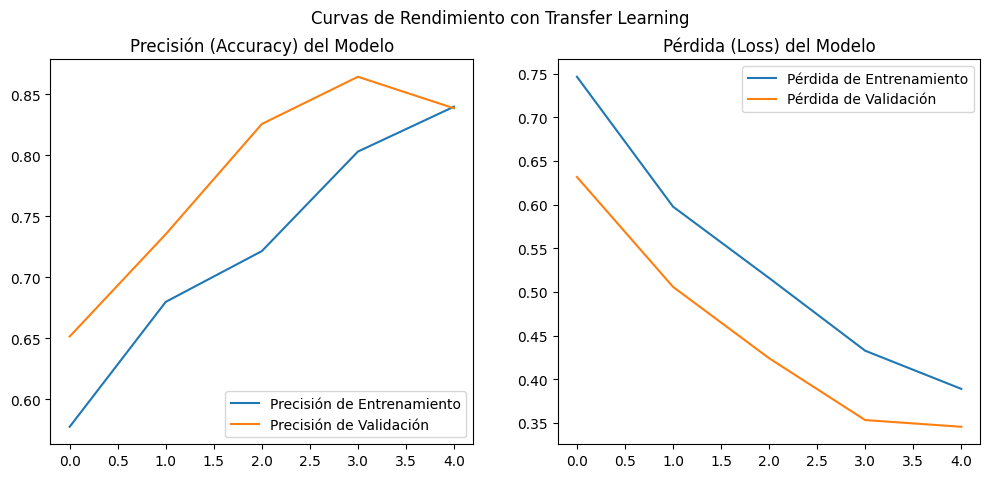

In [ ]:
# Visualizamos las curvas de aprendizaje para diagnosticar el comportamiento del modelo:
# si las curvas de entrenamiento y validación se mantienen cercanas, el modelo generaliza bien;
# si divergen, hay sobreajuste (overfitting).
acc     = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss    = historial.history['loss']
val_loss = historial.history['val_loss']
epocas_rango = range(EPOCAS)

plt.figure(figsize=(12, 5))

# Grafico izquierdo: precisión — idealmente ambas curvas suben juntas hacia 1.0.
plt.subplot(1, 2, 1)
plt.plot(epocas_rango, acc, label='Precisión de Entrenamiento')
plt.plot(epocas_rango, val_acc, label='Precisión de Validación')
plt.title('Precisión (Accuracy) del Modelo')
plt.legend(loc='lower right')  # La precisión empieza baja y sube, por eso la leyenda va abajo a la derecha.

# Grafico derecho: pérdida — idealmente ambas curvas bajan juntas hacia 0.
plt.subplot(1, 2, 2)
plt.plot(epocas_rango, loss, label='Pérdida de Entrenamiento')
plt.plot(epocas_rango, val_loss, label='Pérdida de Validación')
plt.title('Pérdida (Loss) del Modelo')
plt.legend(loc='upper right')  # La pérdida empieza alta y baja, por eso la leyenda va arriba a la derecha.

plt.suptitle('Curvas de Rendimiento con Transfer Learning')
plt.show()


## Consigna de Lectura e Interpretación

Analicen detenidamente las curvas de precisión y error obtenidas.  

**¿Qué exactitud se alcanzó desde la primera época de entrenamiento?**
- **58 % de exactitud en entrenamiento**.
- **65 % de exactitud en validación**.

**¿A qué atribuyen que el rendimiento escale tan rápidamente a valores tan elevados en comparación con entrenar una red de convolución profunda desde cero?**

El rendimiento crece rápidamente porque MobileNetV2 ya fue entrenada con ImageNet y posee filtros capaces de reconocer bordes, texturas, formas y patrones visuales. En este trabajo, esa base permanece congelada y solamente se entrenan los **2.562 parámetros** de la capa clasificadora para adaptar esas características a las dos categorías.

Las curvas muestran una evolución favorable: la precisión de entrenamiento aumenta hasta cerca del **84 %**, mientras la pérdida baja de aproximadamente `0,75` a `0,39`. La validación alcanza un máximo cercano al **86 %** y termina alrededor del **84 %**.

Que la validación supere inicialmente al entrenamiento puede explicarse por técnicas como **Dropout** y *Data Augmentation*, que hacen más difícil el aprendizaje durante el entrenamiento, pero se desactivan o no se aplican de la misma manera al validar. La pequeña caída final de la precisión de validación podría indicar una variación normal del conjunto o un comienzo leve de sobreajuste, aunque no parece grave.

En comparación, una CNN profunda entrenada desde cero debe aprender simultáneamente las características visuales y la clasificación final. Por eso necesita más épocas, más imágenes y mayor capacidad computacional para alcanzar resultados semejantes.

## Cierre de Laboratorio

Han comprobado y asimilado de forma empírica la formidable técnica de **Transferencia de Aprendizaje (Transfer Learning)**, entrenando un modelo híbrido basado en **MobileNetV2** para un dataset de perros y gatos.

En la siguiente sesión daremos un salto decisivo hacia el estado del arte de la inteligencia artificial visual y utilizaremos pipelines preentrenados del ecosistema oficial de **Hugging Face** para desplegar Vision Transformers (ViT), modelos Zero-Shot (CLIP) y detectores con localización espacial de objetos (DETR).